In [2]:
from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.ion()

In [3]:
# 训练集扩充和归一化
# 在验证集上仅需归一化
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), # 随机裁剪一个area然后再resize
        transforms.RandomHorizontalFlip(), # 随机水平翻转
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

data_dir = 'data/hymenoptera_data'
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']
}
dataloaders = {
    x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4) for x in ['train', 'val']
}
dataset_sizes = {
    x: len(image_datasets[x]) for x in ['train', 'val']
}
class_names = image_datasets['train'].classes

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

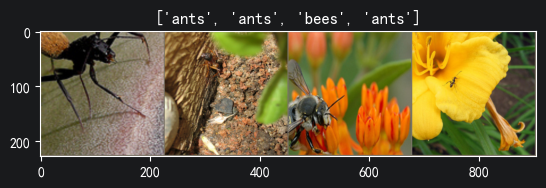

In [4]:
def imshow(inp, title=None):
    """image show for tensor"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001) # pause a bit so that plots are updated

# 获取一批训练数据
inputs, classes = next(iter(dataloaders['train']))
# 批量制作网格
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=35):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        #每个epoch都有一个训练和验证阶段
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval() # set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # 统计
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        scheduler.step()
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    #加载最佳模型权重
    model.load_state_dict(best_model_wts)
    return model

In [ ]:
# 一个通用的展示少量预测图片的函数
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(model=was_training)

In [12]:
# 场景1: 微调ConvNet
# 加载预训练模型并重置最终完全连接的图层
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_fits = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_fits, 2)

model_ft = model_ft.to(device)
criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6839 Acc: 0.6516
val Loss: 0.2186 Acc: 0.9412

Epoch 1/24
----------
train Loss: 0.6082 Acc: 0.7623
val Loss: 0.2640 Acc: 0.9020

Epoch 2/24
----------
train Loss: 0.5183 Acc: 0.8238
val Loss: 0.4754 Acc: 0.8170

Epoch 3/24
----------
train Loss: 0.5768 Acc: 0.7746
val Loss: 0.5400 Acc: 0.8431

Epoch 4/24
----------
train Loss: 0.6599 Acc: 0.7828
val Loss: 0.3930 Acc: 0.8562

Epoch 5/24
----------
train Loss: 0.5307 Acc: 0.7869
val Loss: 0.3848 Acc: 0.8366

Epoch 6/24
----------
train Loss: 0.3731 Acc: 0.8484
val Loss: 0.2164 Acc: 0.9216

Epoch 7/24
----------
train Loss: 0.4017 Acc: 0.8443
val Loss: 0.1856 Acc: 0.9216

Epoch 8/24
----------
train Loss: 0.3880 Acc: 0.8402
val Loss: 0.1977 Acc: 0.9216

Epoch 9/24
----------
train Loss: 0.3987 Acc: 0.8320
val Loss: 0.1959 Acc: 0.9281

Epoch 10/24
----------
train Loss: 0.3999 Acc: 0.8279
val Loss: 0.2193 Acc: 0.9150

Epoch 11/24
----------
train Loss: 0.3258 Acc: 0.8525
val Loss: 0.1763 Acc: 0.9477

Ep

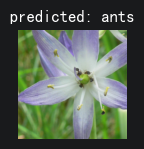

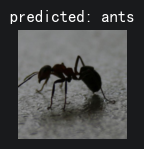

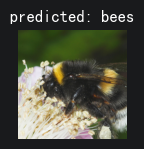

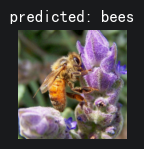

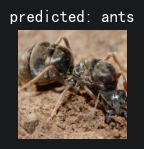

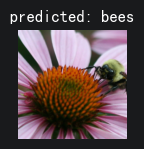

In [13]:
visualize_model(model_ft)

In [14]:
# 场景2: ConvNet作为固定特征提取器
model_conv = torchvision.models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_conv.parameters():
    param.requires_grad = False

num_frts = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_frts, 2)

model_conv = model_conv.to(device)
criterion = nn.CrossEntropyLoss()

optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5834 Acc: 0.6885
val Loss: 0.2919 Acc: 0.8889

Epoch 1/24
----------
train Loss: 0.4976 Acc: 0.7254
val Loss: 0.2189 Acc: 0.9085

Epoch 2/24
----------
train Loss: 0.4277 Acc: 0.8197
val Loss: 0.1885 Acc: 0.9216

Epoch 3/24
----------
train Loss: 0.4972 Acc: 0.7787
val Loss: 0.2008 Acc: 0.9412

Epoch 4/24
----------
train Loss: 0.4676 Acc: 0.7869
val Loss: 0.1672 Acc: 0.9412

Epoch 5/24
----------
train Loss: 0.3518 Acc: 0.8279
val Loss: 0.3153 Acc: 0.8758

Epoch 6/24
----------
train Loss: 0.5611 Acc: 0.7623
val Loss: 0.3105 Acc: 0.8889

Epoch 7/24
----------
train Loss: 0.3647 Acc: 0.8607
val Loss: 0.1825 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.3619 Acc: 0.8361
val Loss: 0.2066 Acc: 0.9346

Epoch 9/24
----------
train Loss: 0.2940 Acc: 0.8648
val Loss: 0.1771 Acc: 0.9412

Epoch 10/24
----------
train Loss: 0.3082 Acc: 0.8525
val Loss: 0.2058 Acc: 0.9346

Epoch 11/24
----------
train Loss: 0.3602 Acc: 0.8156
val Loss: 0.1921 Acc: 0.9216

Ep

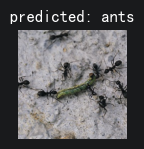

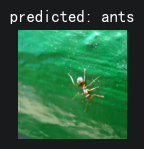

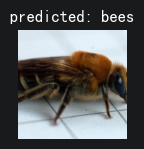

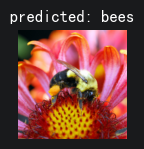

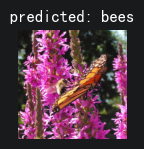

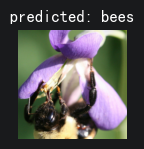

In [15]:
visualize_model(model_conv)
plt.ioff()
plt.show()

In [ ]:
test = transforms.Normalize(                # 标准化（ImageNet均值和标准差）
    [0.485, 0.456, 0.406],           # 均值（R, G, B）
    [0.229, 0.224, 0.225]            # 标准差（R, G, B）
)
test